# Granovetter's Threshold Model of Collective Behavior

**Methods:** Mathematical (mean-field) model vs. agent-based simulation; uniform and normal threshold distributions; NumPy, SciPy, Matplotlib

### Overview
This notebook derives the diffusion equation, then compares the analytical model against an ABM under two threshold distributions.

---

### Derivation of the equation

This section derives multiplicative discrete-time dynamic update model [Equation (1)] from discrete-time dynamic update model [Equation (2)]. The calculation process is shown step by step to obtain Equation (1).

Equation (1) Percentage of adopters at time t ($P_t$) [Target equation]:

$$
P_{t+1} = \left[ 1 + \gamma b \{ \varphi_0 - P_t + (1 - \varphi_0) F(\alpha P_t) \} \right] P_t \tag{1}
$$

Equation (2) Discrete-time dynamic update model [Starting equation]:

$$
P_{t+1} = (1 - \gamma B(P_t)) P_t + \gamma B(P_t) \left[ F(\alpha P_t) + \int_{\alpha P_t}^{\infty} \varphi_0(e) f(e) \, de \right] \tag{2}
$$

---

From $\varphi_0(e) = \varphi_0$, and $B(P)=bP$

$$
P_{t+1} = (1 - \gamma bP_t) P_t + \gamma bP_t \left[ F(\alpha P_t) + \int_{\alpha P_t}^{\infty} \varphi_0 f(e) \, de \right]
$$

Since $\varphi_0$ is constant

$$
P_{t+1} = (1 - \gamma bP_t) P_t + \gamma bP_t \left[ F(\alpha P_t) + \varphi_0 \int_{\alpha P_t}^{\infty} f(e) \, de \right]
$$

Take integrate

$$
P_{t+1} = (1 - \gamma bP_t) P_t + \gamma bP_t \left[ F(\alpha P_t) + \varphi_0 [F(e)]_{e=\alpha P_t}^{\infty} \right]
$$

from

$$
f(e) =
\begin{cases}
    \frac{1}{\theta \alpha} & \text{if } 0 < e \leq \theta \alpha \\
    0, & \text{otherwise}
\end{cases}
\quad \text{where } 0 < \theta \leq 1
$$

we will also get the condition of $F(x)$ as follow

$$
F(x) =
\begin{cases}
    0, & \text{if } e \leq 0 \\
    \frac{x}{\theta \alpha}, & \text{if } 0 < e \leq \theta \alpha \\
    1, & \text{if } e > \theta \alpha
\end{cases}
$$

we then use the condition of $F(x)$:

$$
P_{t+1} = (1 - \gamma bP_t) P_t + \gamma bP_t \left[ F(\alpha P_t) + \varphi_0 [1-F(\alpha P_t)] \right]
$$

Distribute $\varphi_0$ in

$$
P_{t+1} = (1 - \gamma bP_t) P_t + \gamma b P_t \left[ F(\alpha P_t) + \varphi_0 - \varphi_0 F(\alpha P_t) \right]
$$

Arrange and pull $F(\alpha P_t)$ out

$$
P_{t+1} = (1 - \gamma bP_t) P_t + \gamma b P_t \left[ \varphi_0 + (1 - \varphi_0) F(\alpha P_t) \right]
$$

Distribute the $P_t$ and $\gamma b P_t$ and arrange

$$
P_{t+1} = P_t + \gamma b P_t \varphi_0 - \gamma b P_t P_t + \gamma b P_t(1 - \varphi_0) F(\alpha P_t)
$$

Pull $\gamma b P_t$ out

$$
P_{t+1} = P_t + \gamma b P_t \{ \varphi_0 - P_t + (1 - \varphi_0) F(\alpha P_t) \}
$$

Pull $P_t$ out

$$
P_{t+1} = \left[ 1 + \gamma b \{ \varphi_0 - P_t + (1 - \varphi_0) F(\alpha P_t) \} \right] P_t
$$

Hence, we derived equation (1) from equation (2).

---

### Numerical Calculations

Numerical calculation of the time change of the adopter when the threshold distribution is normal with `P0_case of 0.02, 0.05, 0.10` and show the graph

### Program

Import necessary libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import norm

From distribution function of threshold:

$$
f(e) = \frac{1}{\sigma \sqrt{2\pi}} e^{-(e-e_{mean})^2 / 2\sigma^2}
$$

we then define the threshold distribution function $F(\alpha P_t)$

$$
F(\alpha P_t) = \int_{-\infty}^{\alpha P_t} f(e) de = \frac{1}{\sqrt{\pi}} \int_{-\infty}^{(P_t - \frac{e_{mean}}{\alpha}) / (\sigma \sqrt{2} / \alpha)} e^{-x^2} dx
$$

Call that standard normal CDF is as follow:

$$
\Phi(z) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{z} \exp \left( -\frac{u^2}{2} \right) du
$$

Using the equivalence between the two forms, we get:

$$
F(\alpha P_t) = \Phi \left( \frac{\alpha P_t - e_{\text{mean}}}{\sigma} \right)
$$

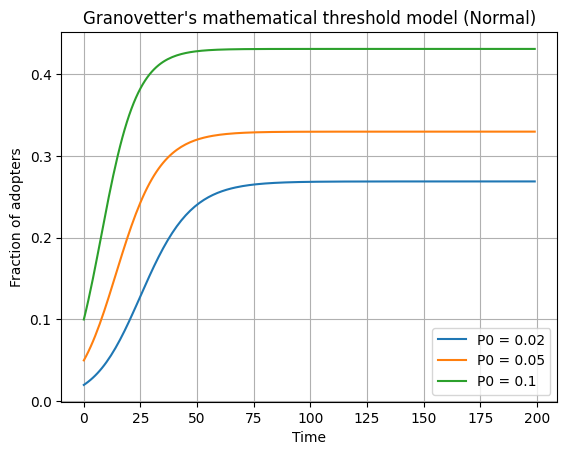

In [2]:
laststep=200
rb=0.8 # rb = gamma*b
theta=0.6
alpha = 1.0
mu = 0.6
sigma = 0.5

P0_case = [0.02, 0.05, 0.10]

for P0 in P0_case:
  density = np.zeros(laststep)
  time = np.arange(laststep)

  density[0]=P0
  P=P0 #initial setting

  for t in range(1, laststep):
    P = (1 + rb * (P0 - P + (1 - P0) * norm.cdf((alpha * P - mu) / sigma))) * P # F = 1.0 # F = norm.cdf((alpha * P - mu) / sigma)
    density[t]=P

  plt.plot(time, density, label=f'P0 = {P0}')

plt.title("Granovetter's mathematical threshold model (Normal)")
plt.xlabel("Time")
plt.ylabel("Fraction of adopters")
plt.legend()
plt.grid(True)
plt.show()

---

### Compare the Results of Mathematical Models and ABM

1. Uniformly Random Threshold Distribution
2. Normally Distributed Thresholds


---

#### 1. Uniformly Random Threshold Distribution

The results of the mathematical model and ABM are compared when the threshold distribution is uniformly random.

#### Mathematical model (uniform thresholds)

Recall,

\begin{equation}
F(x) =
\begin{cases}
0, & \text{if } e \leq 0 \\
\frac{x}{\theta \alpha}, & \text{if } 0 < e \leq \theta \alpha \\
1, & \text{if } e > \theta \alpha
\end{cases}
\end{equation}

substitute $\alpha P_t$ in to $x$

\begin{equation}
F(\alpha P_t) =
\begin{cases}
0, & \text{if } P_t \leq 0 \\
\frac{P_t}{\theta}, & \text{if } 0 < P_t \leq \theta \alpha \\
1, & \text{if } P_t > \theta \alpha
\end{cases}
\end{equation}

Similar to Granovetter's mathematical threshold model (Normal), but we modified to uniform random thresholds instead of normal random number as follows:

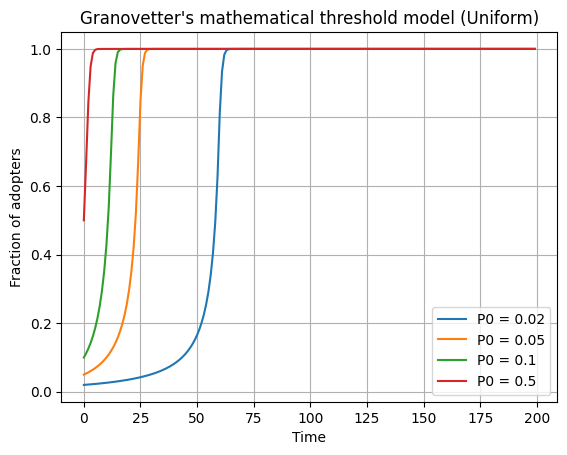

In [3]:
laststep=200
rb=0.8 # rb = gamma*b
theta=0.6
alpha = 1.0

P0_case = [0.02, 0.05, 0.10, 0.5]

for P0 in P0_case:
  density = np.zeros(laststep)
  time = np.arange(laststep)

  density[0]=P0
  P=P0 #initial setting

  for t in range(1, laststep):
    if P <= theta: #Use the derived eqn.
      P = (1 + rb * (P0 - P + (1 - P0) * P / theta)) * P
    elif P > theta:# F(alpha*P_t) = 1
      P = (1 + rb * (P0 - P + (1 - P0) * 1.0)) * P # F = 1.0
    density[t]=P

  plt.plot(time, density, label=f'P0 = {P0}')

plt.title("Granovetter's mathematical threshold model (Uniform)")
plt.xlabel("Time")
plt.ylabel("Fraction of adopters")
plt.legend()
plt.grid(True)
plt.show()

#### ABM Model (uniform thresholds)

ABM structure provided in course; mean-field comparison model and analysis are my own.

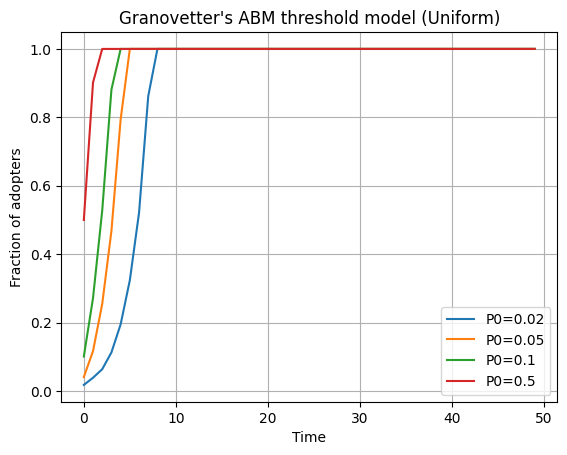

In [7]:
P0_case = [0.02, 0.05, 0.1, 0.5]

for P0 in P0_case:
  n=1000 # population size
  a=1 #alpha in the model
  laststep=50
  theta = 0.6

  threshold=[random.uniform(0,theta) for i in range(0,n)] # 0 <= e <= 1, uniform random
  #threshold=[random.gauss(mu=0.6,sigma=0.5) for i in range(0,n)]
  acceptance=[0 for i in range(0,n)] # 1 = accepted, 0=none

  densityP = np.zeros(laststep)
  time = np.arange(laststep)
  time[0]=0

  #initial acceptance
  P=0
  for i in range(0,n):
    if(P0>random.random()):
      acceptance[i]=1
      P=P+1

  densityP[0]=P/n


  for t in range(1, laststep):

    for i in range(0,n):
      if acceptance[i]==0: # non-accepter
        if threshold[i]<= a*P/n:
          acceptance[i]=1

    P=0
    for i in range(0,n):
      if acceptance[i]==1:
        P=P+1

    densityP[t]=P/n
    time[t]=t


  plt.plot(time,densityP,label=f'P0={P0}')

plt.title("Granovetter's ABM threshold model (Uniform)")
plt.xlabel("Time")
plt.ylabel("Fraction of adopters")
plt.legend()
plt.grid(True)
plt.show()

#### Discuss comparison between mathematical model and ABM model (uniform thresholds)

Both models show rapid convergence, a clear tipping point and similar equilibrium value. Due to their uniform distribution has bounded support, their long term outcome is going to be converges to stable equilibrium with similar behavior.

Initial fraction of adopters $P_0$ can directly effect how much time it takes to converge to the equlibrium point for both model.

However, the ABM exhibits faster initial growth than the mathematical model. This occurs because, in the ABM, agents with very low thresholds adopt immediately. As the population size increases and the threshold range becomes narrower, the ABM results approach those of the mathematical model, indicating that the mean-field approximation becomes more accurate in the large-n limit.


---

### 2. Normally Distributed Thresholds

#### Mathematical model (normal thresholds)

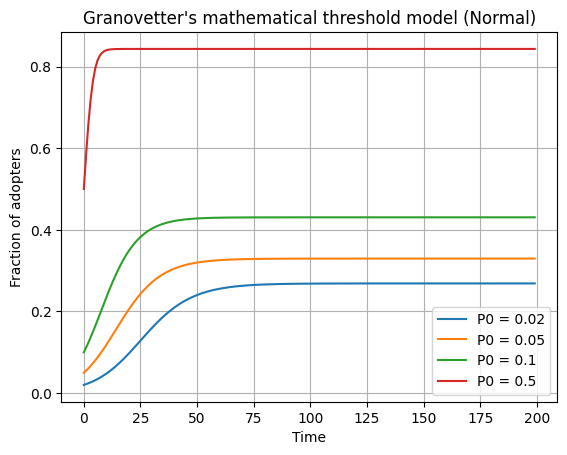

In [5]:
laststep=200
rb=0.8 # rb = gamma*b
theta=0.6
alpha = 1.0
mu = 0.6
sigma = 0.5

P0_case = [0.02, 0.05, 0.10, 0.5]

for P0 in P0_case:
  density = np.zeros(laststep)
  time = np.arange(laststep)

  density[0]=P0
  P=P0 #initial setting

  for t in range(1, laststep):
    P = (1 + rb * (P0 - P + (1 - P0) * norm.cdf((alpha * P - mu) / sigma))) * P # F = 1.0 # F = norm.cdf((alpha * P - mu) / sigma)
    density[t]=P

  plt.plot(time, density, label=f'P0 = {P0}')

plt.title("Granovetter's mathematical threshold model (Normal)")
plt.xlabel("Time")
plt.ylabel("Fraction of adopters")
plt.legend()
plt.grid(True)
plt.show()

#### ABM model (normal thresholds)

ABM structure provided in course; mean-field comparison model and analysis are my own.

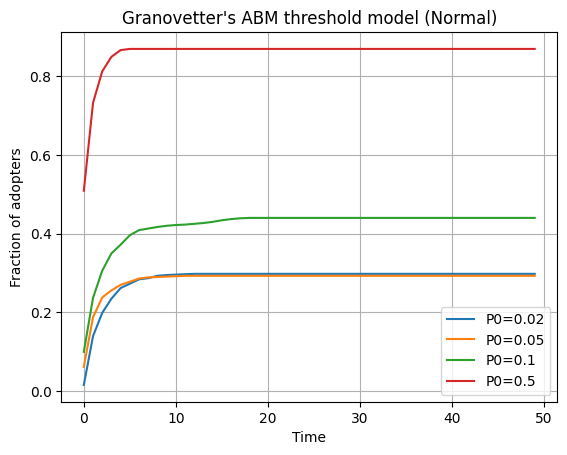

In [6]:
P0_case = [0.02, 0.05, 0.1, 0.5]

for P0 in P0_case:
  n=1000 # population size
  a=1 #alpha in the model
  laststep=50
  theta = 0.6

  #threshold=[random.uniform(0,theta) for i in range(0,n)] # 0 <= e <= 1, uniform random
  threshold=[random.gauss(mu=0.6,sigma=0.5) for i in range(0,n)]
  acceptance=[0 for i in range(0,n)] # 1 = accepted, 0=none

  densityP = np.zeros(laststep)
  time = np.arange(laststep)
  time[0]=0

  #initial acceptance
  P=0
  for i in range(0,n):
    if(P0>random.random()):
      acceptance[i]=1
      P=P+1

  densityP[0]=P/n


  for t in range(1, laststep):

    for i in range(0,n):
      if acceptance[i]==0: # non-accepter
        if threshold[i]<= a*P/n:
          acceptance[i]=1

    P=0
    for i in range(0,n):
      if acceptance[i]==1:
        P=P+1

    densityP[t]=P/n
    time[t]=t


  plt.plot(time,densityP,label=f'P0={P0}')

plt.title("Granovetter's ABM threshold model (Normal)")
plt.xlabel("Time")
plt.ylabel("Fraction of adopters")
plt.legend()
plt.grid(True)
plt.show()

---

#### Discuss comparison between mathematical model and ABM model (normal thresholds)

Both the mathematical model and the ABM show a clear increase in the fraction of adopters over time and eventually reach a stable equilibrium. The final equilibrium value is often similar in both models when the parameters are the same. The initial fraction of adopters $P_0$ plays an important role in both models, as a larger $P_0$ leads to faster convergence to the equilibrium.

However, the ABM usually shows faster adoption at the early stage compared to the mathematical model. This happens because, in the ABM, some agents are located in the lower tail of the normal distribution and have very small thresholds, so they adopt immediately and speed up the diffusion process.

In contrast, the mathematical model averages the behavior of all agents and produces a smoother and slower increase. As the population size becomes larger, the ABM results become closer to those of the mathematical model, since random fluctuations are reduced and the mean-field approximation becomes more accurate.